# <div align="center"><u>MLP High Spearman's Rank Correlation</u>

##############################################################################################################################

###  Import some useful libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import random
import time

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

### Suppress warnings

In [2]:
# import warnings

# # To suppress all warnings
# warnings.filterwarnings("ignore")

### Start time

In [3]:
# Start time
start_time = time.time()

### Load the colon-kidney high spearman's rank correlation filtered capped dataset and store it within a pandas DataFrame

In [4]:
# Load the dataset and store it withina  panda dataframe to handle it easier
df = pd.read_csv(r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\High Correlation Filters\Spearman's Rank Correlation\The colon-kidney high spearman's rank correlation filtered capped dataset.csv")

# Print the dataset
df

,1555989_at,1561817_at,1569532_a_at,200697_at,201397_at,201542_at,202965_s_at,202991_at,203673_at,203815_at,...,232252_at,235333_at,235737_at,235763_at,238717_at,239990_at,240717_at,243938_x_at,Target,Tissue
0,996.5,85.300,34.600,1619.5,688.8,2742.9,58.7,215.000,125.3,2125.3,...,98.9000,491.5000,55.4,82.4,513.400,46.1,8.1,93.8,0.0,Kidney
1,256.4,30.100,37.800,1874.4,195.4,2549.5,3.6,342.900,135.2,1953.9,...,54.6000,151.4000,8.7,14.4,228.300,43.0,36.0,108.8,0.0,Kidney
2,458.8,20.100,260.900,1934.8,466.1,3294.8,62.0,215.100,343.4,1184.9,...,230.5000,1239.1125,19.0,17.7,1216.725,55.3,62.7,111.4,0.0,Kidney
3,892.1,102.700,52.800,1935.2,571.0,2498.4,26.5,337.800,158.4,921.9,...,74.5000,309.6000,74.2,47.5,50.600,15.7,64.3,7.0,0.0,Kidney
4,830.2,105.600,66.900,2082.8,373.2,3128.0,266.9,265.200,245.6,26.7,...,200.3000,475.0000,18.8,660.7,711.800,67.2,46.2,127.4,0.0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,265.6,40.200,15.600,1377.3,799.6,2002.5,28.6,599.625,253.0,479.4,...,477.6625,633.4000,11.3,22.1,69.600,15.9,14.9,7.3,1.0,Colon
542,368.6,219.075,92.300,2093.9,884.1,3110.0,423.9,258.500,150.9,340.5,...,50.3000,492.6000,27.1,270.8,471.600,29.8,37.1,101.9,1.0,Colon
543,459.2,41.000,321.575,1392.9,463.7,2510.7,362.1,599.625,111.9,1059.5,...,135.4000,487.5000,122.3,40.8,54.500,89.8,7.6,81.6,1.0,Colon
544,457.7,48.700,85.600,1396.1,586.8,2650.6,16.0,381.700,290.8,830.1,...,434.2000,664.4000,131.3,373.3,124.300,16.0,68.4,9.6,1.0,Colon


### Define parameters

In [5]:
# Define parameters
number_of_splits = 50       # Number of MCCV iterations
test_size = 0.25            # 25% test data
number_of_layers = 100      # Hidden layer neurons
learning_rate = 0.001       # Learning rate

### Prepare data

In [6]:
# Prepare data
X = df.iloc[:, :-2].values  # Features
y = df['Target'].values     # Classes-Labels

### Function that applies Monte Carlo Cross Validation (MCCV)

In [7]:
# Function that applies Monte Carlo Cross Validation
def MLP_MCCV(X, y, number_of_layers, learning_rate, test_size=0.25, num_splits=50):
    
    train_scores = np.zeros(num_splits)
    test_scores = np.zeros(num_splits)
    train_losses = np.zeros(num_splits)
    test_losses = np.zeros(num_splits)

    test_precision_scores = np.zeros(num_splits)
    test_recall_scores = np.zeros(num_splits)
    test_f1_scores = np.zeros(num_splits)
    test_auc_roc_scores = np.zeros(num_splits)

    # Get number of classes
    labels = np.unique(y)
    n_classes = len(labels)

    # Initialize accumulator for confusion matrices
    cm_total = np.zeros((n_classes, n_classes), dtype=np.float64)

    for i in range(num_splits):
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, shuffle=True, stratify=y, random_state=i
        )

        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        model = MLPClassifier(
            hidden_layer_sizes=(number_of_layers,),
            activation='relu',
            solver='adam',
            learning_rate_init=learning_rate,
            max_iter=270,
            random_state=i
        )

        model.fit(x_train_scaled, y_train)

        y_train_pred = model.predict(x_train_scaled)
        y_test_pred = model.predict(x_test_scaled)
        y_train_proba = model.predict_proba(x_train_scaled)
        y_test_proba = model.predict_proba(x_test_scaled)

        train_scores[i] = accuracy_score(y_train, y_train_pred)
        test_scores[i] = accuracy_score(y_test, y_test_pred)
        train_losses[i] = log_loss(y_train, y_train_proba)
        test_losses[i] = log_loss(y_test, y_test_proba)

        # Calculate and store precision, recall, f1_score and AUC-ROC metrics for the test set
        test_precision_scores[i] = precision_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_recall_scores[i] = recall_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_f1_scores[i] = f1_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_auc_roc_scores[i] = roc_auc_score(y_test, y_test_proba[:, 1])

        # Add normalized confusion matrix to accumulator
        cm = confusion_matrix(y_test, y_test_pred, labels=labels)
        cm_total += cm

    # Average confusion matrix
    cm_avg = cm_total / num_splits

    return (
        train_scores,
        test_scores,
        train_losses,
        test_losses,
        test_precision_scores,
        test_recall_scores,
        test_f1_scores,
        test_auc_roc_scores,
        cm_avg,
        labels,
    )

### Apply MCCV

In [8]:
train_scores, test_scores, train_losses, test_losses, \
test_precision_scores, test_recall_scores, test_f1_scores, test_auc_roc_scores, \
cm_avg, labels = MLP_MCCV(
    X, y, number_of_layers=number_of_layers, learning_rate=learning_rate, test_size=test_size, num_splits=number_of_splits
)

### Print results

In [9]:
print(f"Avg Training Accuracy: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
print(f"Avg Evaluation Accuracy:  {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")

Avg Training Accuracy: 1.0000 ± 0.0000
Avg Evaluation Accuracy:  0.8429 ± 0.0314


In [10]:
print(f"Avg Training Log Loss: {np.mean(train_losses):.4f} ± {np.std(train_losses):.4f}")
print(f"Avg Evaluation Log Loss:  {np.mean(test_losses):.4f} ± {np.std(test_losses):.4f}")

Avg Training Log Loss: 0.0085 ± 0.0005
Avg Evaluation Log Loss:  0.5200 ± 0.1234


In [11]:
print(f"Avg Evaluation Precision: {np.mean(test_precision_scores):.4f} ± {np.std(test_precision_scores):.4f}")
print(f"Avg Evaluation Recall:    {np.mean(test_recall_scores):.4f} ± {np.std(test_recall_scores):.4f}")
print(f"Avg Evaluation F1-Score:  {np.mean(test_f1_scores):.4f} ± {np.std(test_f1_scores):.4f}")
print(f"Avg Evaluation AUC-ROC:   {np.mean(test_auc_roc_scores):.4f} ± {np.std(test_auc_roc_scores):.4f}")

Avg Evaluation Precision: 0.8445 ± 0.0307
Avg Evaluation Recall:    0.8429 ± 0.0314
Avg Evaluation F1-Score:  0.8428 ± 0.0314
Avg Evaluation AUC-ROC:   0.9103 ± 0.0242


### Accuracy over MCCV iterations

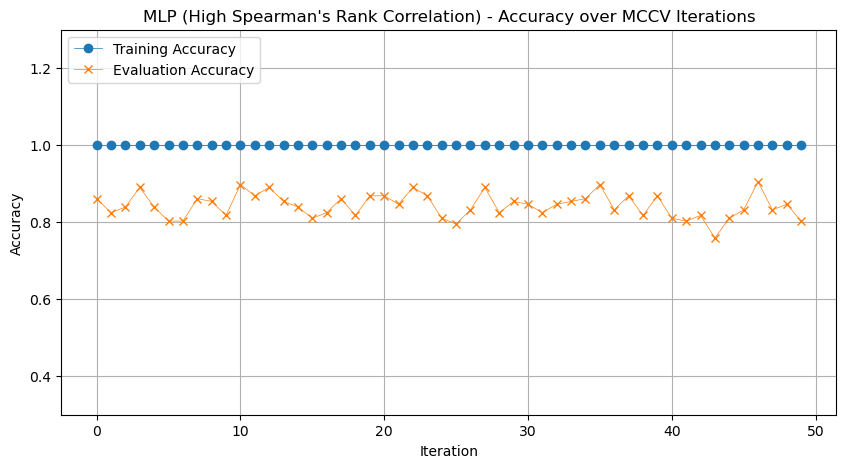

In [12]:
# Accuracy over MCCV iterations
plt.figure(figsize=(10, 5))
plt.plot(train_scores, label='Training Accuracy', marker='o', linewidth=0.5)
plt.plot(test_scores, label='Evaluation Accuracy', marker='x', linewidth=0.5)
plt.title("MLP (High Spearman's Rank Correlation) - Accuracy over MCCV Iterations")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.legend(loc='upper left')
plt.ylim(0.3, 1.3)
plt.show()

### Log loss over MCCV iterations

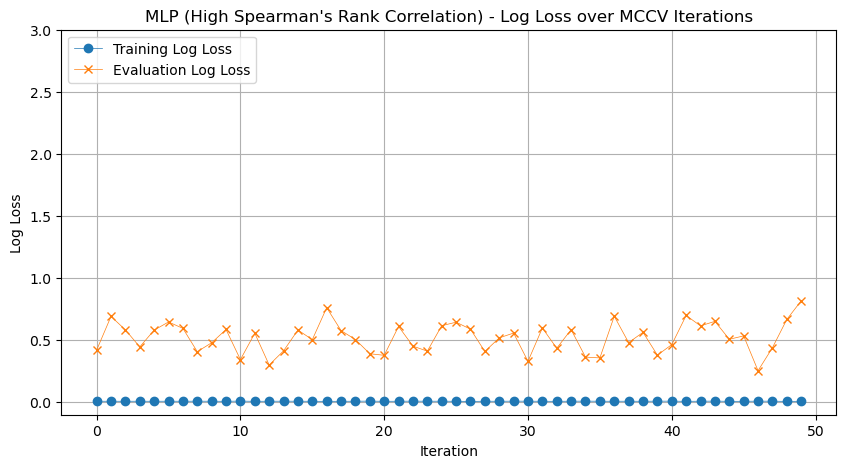

In [13]:
# Log loss over MCCV iterations
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Log Loss', marker='o', linewidth=0.5)
plt.plot(test_losses, label='Evaluation Log Loss', marker='x', linewidth=0.5)
plt.title("MLP (High Spearman's Rank Correlation) - Log Loss over MCCV Iterations")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.legend(loc='upper left')
plt.ylim(-0.1, 3.0)
plt.show()

### Plot the average confussion matrix

In [14]:
# Function that plots the average confussion matrix
def plot_confusion_matrix(cm, labels, title="MLP (High Spearman's Rank Correlation) MCCV - Average Confusion Matrix", cmap='Blues'):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=labels,
                yticklabels=labels)

    plt.title(title, fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

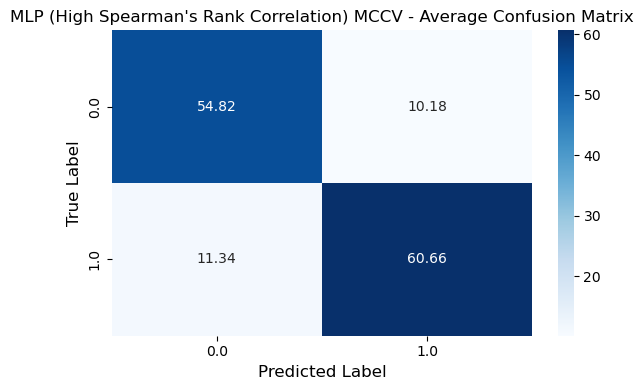

In [15]:
# Plot confusion matrix
plot_confusion_matrix(cm_avg, labels)

### End time

In [16]:
# End time
end_time = time.time()

### Elapsed time

In [17]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for MLP (High Spearman's Rank Correlation): {elapsed_time:.2f} seconds")

Elapsed time for MLP (High Spearman's Rank Correlation): 33.06 seconds
